## Customer Segmentation and Marketing Strategy Analysis
### Using RFM Analysis and K-Means Clustering
**Tools:** Python | Pandas | NumPy | Scikit-learn | Matplotlib


### 1. Excecutive Summary
#### Business Background
A UK-based online retail client operates its own online shopping website, selling unique all-occasion gifts. Many customers of the company are wholesalers. While they have accumulated a large volume of customer transaction data over time, its marketing strategy has not fully leveraged customer purchasing behavior.

Although the company has collected detailed transaction data, it has not previously implemented a formal customer segmentation strategy. As a result, customer behavior has not been systematically analyzed to support personalized marketing or customer relationship management initiatives.

#### Problem Statement
One of the company's primary marketing channels is email marketing. The company currently sends the identical promotional email to all customers without considering differences in shopping habits, purchasing frequency, or customer value. This one-size-fits-all approach has already led to low engagement, inefficient marketing spending, and missed opportunities to strengthen relationships with high-value customers while effectively nurturing potential loyal customers.

To improve marketing effectiveness, the marketing team aims to establish its first customer segmentation framework using historical transaction data. By grouping customers based on their purchasing behavior, the company can deliver more personalized email campaigns tailored to different customer cohorts, ultimately improving customer engagement, retention, and overall performance.

#### Project Objective
The objective of this project is to support the marketiing team to develop a data-driven customer segmentation framework using historical customer transaction data. As the Data Analyst, my role is to transform raw transaction records into actionable customer insights that enable more personalized and effective marketing strategies.

Specifically, this project aims to:
- Aggregate transaction-level data into customer-level behavioral metrics using the **Recency, Frequency, and Monetary (RFM) framework**.
- Identify distinct customer segments based on purchasing behavior and customer value.
- Analyze the characteristics and purchasing patterns of each customer segment.
- Translate analytical findings into actionable marketing recommendations for personalized email campaigns.
- Provide a data-driven foundation for future customer relationship management (CRM) initiatives and marketing performance evaluation.

#### Success Metrics

Although this analysis is performed using historical transaction data, the success of a personalized email strategy could be evaluated through future marketing campaigns using metrics such as:

- Email open rate
- Click-through rate (CTR)
- Conversion rate
- Repeat purchase rate
- Revenue per customer
- Customer retention rate


### 2. Data Overview
Before performing customer segmentation, it is important to understand the structure and quality of the available data. The dataset consists of historical transaction records collected from the company's online shopping platform. Each record represents a single product purchased within an order rather than an individual customer.

Because the business objective is to segment customers based on purchasing behavior, the transaction-level data will later be aggregated into customer-level metrics.

#### Dataset Description
The dataset contains historical online retail transactions from December 2009 to December 2011.

Each row represents a single purchased item within a customer's order.

The key variables used in this project are summarized below.
| Variable | Data Type | Description | Business Purpose |
|-----------|-----------|-------------|------------------|
| **InvoiceNo** | String | Unique invoice number assigned to each transaction. | Identify individual orders and distinguish completed purchases from cancellations. |
| **StockCode** | String | Unique identifier for each product. | Track products purchased by customers. |
| **Description** | String | Product name or description. | Interpret products during exploratory analysis and reporting. |
| **Quantity** | Integer | Number of units purchased in each transaction. | Measure purchasing volume and calculate total sales. |
| **InvoiceDate** | Datetime | Date and time when the transaction occurred. | Calculate customer recency and analyze purchasing trends over time. |
| **UnitPrice** | Float | Price of a single product unit (£). | Calculate transaction value and customer spending. |
| **CustomerID** | Integer | Unique identifier assigned to each customer. | Aggregate transactions to the customer level for segmentation. |
| **Country** | String | Country where the customer is located. | Analyze customer distribution across geographic regions. |

#### Analytical Unit
Although the raw dataset is stored at the **transaction level**, the analysis will ultimately be conducted at the **customer level**.

This means that multiple purchases made by the same customer will be combined to calculate behavioral metrics (RMF) such as:

- **Recency** – How recently the customer made a purchase.
- **Frequency** – How often the customer purchases.
- **Monetary** – How much the customer has spent.

These metrics provide a concise summary of each customer's purchasing behavior and serve as the foundation for customer segmentation.

#### Initial Data Exploration
Before performing any analysis, we first examine the dataset to understand its overall structure.

The following steps are performed:

- Preview the first few observations (head())
- Check the dataset dimensions
- Review data types
- Generate descriptive statistics
- Identify missing values
- Check for duplicate records

These exploratory checks help identify potential data quality issues that should be addressed before building customer segments.

In [1]:
# import statements
# dataframe and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
# import dataset
retail = pd.read_csv('retail.csv')
retail

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,12/4/11 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,12/4/11 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,12/4/11 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,12/4/11 13:15,2.89,16931.0,United Kingdom


In [3]:
print('The size of Dataframe is: ', retail.shape)
print('The Column Name, Record Count and Data Types are as follows: ')
retail.info()

The size of Dataframe is:  (1048575, 8)
The Column Name, Record Count and Data Types are as follows: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [4]:
# Defining numerical & categorical columns
numeric_features = [feature for feature in retail.columns if retail[feature].dtype != 'O']
categorical_features = [feature for feature in retail.columns if retail[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['Quantity', 'Price', 'Customer ID']

We have 5 categorical features : ['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [5]:
# Checking for missing values
missing_values = retail.isnull().sum().sort_values(ascending=False)
percent_missing = (retail.isnull().sum() / retail.isnull().count()*100).sort_values(ascending=False)

# Combine into a single DataFrame
pd.concat([missing_values, percent_missing], axis=1, keys=['Total', 'Percent'])


,Total,Percent
Customer ID,236682,22.571776
Description,4372,0.416947
Invoice,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [6]:
# Summary statistics of the dataset
print('Summary Statistics of numerical features for DataFrame are as follows:')
retail[numeric_features].describe()

Summary Statistics of numerical features for DataFrame are as follows:


,Quantity,Price,Customer ID
count,1.048575e+06,1.048575e+06,811893.000000
mean,9.957525e+00,4.627346e+00,15324.712265
std,1.335187e+02,1.228024e+02,1697.033034
min,-7.421500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13971.000000
50%,3.000000e+00,2.100000e+00,15260.000000
75%,1.000000e+01,4.150000e+00,16795.000000
max,7.421500e+04,3.897000e+04,18287.000000


In [7]:
# Checking for unique categories in categorical variables
print("'Customer ID' variable have {} unique category : \n{}\n".format(retail['Customer ID'].nunique(), retail['Customer ID'].unique()))

print("'Invoice' variable have {} unique category : \n{}\n".format(retail['Invoice'].nunique(), retail['Invoice'].unique()))

print("'StockCode' variable have {} unique category : \n{}\n".format(retail['StockCode'].nunique(), retail['StockCode'].unique()))

print("'Description' variable have {} unique category : \n{}\n".format(retail['Description'].nunique(), retail['Description'].unique()))

print("'Country' variable have {} unique category : \n{}\n".format(retail['Country'].nunique(), retail['Country'].unique()))

'Customer ID' variable have 5924 unique category : 
[13085. 13078. 15362. ... 15539. 13017. 13153.]

'Invoice' variable have 52961 unique category : 
['489434' '489435' '489436' ... '580500' '580501' '580502']

'StockCode' variable have 5304 unique category : 
['85048' '79323P' '79323W' ... '23561' '23609' '23617']

'Description' variable have 5692 unique category : 
['15CM CHRISTMAS GLASS BALL 20 LIGHTS' 'PINK CHERRY LIGHTS'
 ' WHITE CHERRY LIGHTS' ... 'SET 10 CARDS SWIRLY XMAS TREE 17104' 'wet?'
 'lost??']

'Country' variable have 43 unique category : 
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Japan' 'Denmark' 'Nigeria' 'Netherlands' 'Poland' 'Spain'
 'Channel Islands' 'Italy' 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden'
 'United Arab Emirates' 'Finland' 'Switzerland' 'Unspecified' 'Malta'
 'Bahrain' 'RSA' 'Bermuda' 'Hong Kong' 'Singapore' 'Thailand' 'Israel'
 'Lithuania' 'West Indies' 'Lebanon' 'Korea' 'Brazil' 'Canada' 'Iceland'
 'Saudi A

### 3. Data Cleaning & Preprocessing
High-quality data is essential for producing reliable customer segments and meaningful business insights. Before calculating RFM metrics, the transaction data must be cleaned to ensure that each record accurately reflects customer purchasing behavior.

This section identifies and addresses common data quality issues, including missing customer identifiers, canceled orders, duplicate records, invalid transaction values, and change datatypes if necessary.

#### Data Quality Assessment

The following checks are performed before preprocessing:

- Missing values
- Duplicate records
- Invalid transaction quantities
- Invalid product prices
- Data type validation

In [8]:
# Check 1: Missing values
missing_values = retail.isnull().sum().sort_values(ascending=False)
percent_missing = ((missing_values / len(retail)) * 100).sort_values(ascending=False)

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': percent_missing})
missing_data

,Missing Values,Percentage
Customer ID,236682,22.571776
Description,4372,0.416947
Invoice,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


Observations: 
1. **22.57%** of Customer ID is missing. Drop the rows with missing Customer ID, since Customer ID is essential primary information for customer-level analysis (a transaction cannot be attributed to a customer without it).
2. Missing information about product description doesn't matter for this project.

In [9]:
# Solution for Check 1: Drop empty Customer ID
retail = retail.dropna(subset=['Customer ID'])
retail.shape

(811893, 8)

In [10]:
# Check 2: Invalid values in 'Price'
(retail['Price']<=0).value_counts()

Price
False    811822
True         71
Name: count, dtype: int64

Observation: There exists **invalid values for Price column**. **71 row entries** are less than or equal to 0.

In [11]:
# Solution for Check 2: Drop invalid values in 'Price'
retail = retail[retail['Price'] > 0]
retail.shape

(811822, 8)

In [12]:
# Check 3: Invalid values in 'Quantity'
(retail['Quantity'] < 0).value_counts()

Quantity
False    793309
True      18513
Name: count, dtype: int64

Observation: There exists **invalid values for Quantity column**. **18,513 row entries** are negative (less than 0), representing returns/cancellations. We drop these rows.

In [13]:
# Solution for Check 3: Drop invalid values in 'Quantity'
retail = retail[retail['Quantity'] >= 0]
retail.shape

(793309, 8)

In [14]:
# Check 4 + solution: Datatype Conversion/Validation
retail['Customer ID'] = retail['Customer ID'].astype(str)
retail.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID     object
Country         object
dtype: object

In [15]:
retail

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,12/4/11 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,12/4/11 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,12/4/11 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,12/4/11 13:15,2.89,16931.0,United Kingdom


#### Data Cleaning Summary
The table below summarizes the impact of the data cleaning process, using the actual figures produced by the checks above. By removing incomplete and invalid transaction records, the dataset is better prepared for reliable customer-level analysis and RFM segmentation.

| Metric | Before Cleaning | After Cleaning |
|:-------------------------|---------------:|--------------:|
| Total Transactions | 1,048,575 | **793,309** |
| Unique Customers | 5,924 | 5,860 |
| Missing Customer IDs | 236,682 (22.57%) | 0 |
| Invalid Price (≤ 0) | 71 | 0 |
| Invalid Quantity (< 0) | 18,513 | 0 |

**Note on duplicate records:** The Data Quality Assessment above (Section 3) listed duplicate records as a check to perform, but no `duplicated()`/`drop_duplicates()` step is actually implemented in the code, and the dataset shown here has not been checked for exact duplicate rows (e.g., the same invoice, product, and quantity logged twice). The original version of this table reported "26,479 duplicates removed," but that number did not correspond to any executed code and has been removed. This is called out again in the Improvements section below as a recommended next step.

The data cleaning process removed incomplete customer records and invalid transaction values (non-positive prices and negative quantities, which mostly represent cancellations/returns) to ensure that the analysis reflects genuine purchasing behavior. The resulting dataset provides a reliable foundation for calculating customer-level RFM metrics and performing downstream customer segmentation.

In [16]:
clean_retail = retail.copy()
clean_retail.shape

(793309, 8)

In [17]:
print(clean_retail['Customer ID'].nunique())
print(clean_retail['Customer ID'].isna().sum())

5860
0


### 4. Methodology 1 - RFM Analysis
The cleaned dataset is currently organized at the transaction level, where each row represents a single product purchased within an order. However, customer segmentation requires understanding purchasing behavior at the customer level rather than the transaction level.

To achieve this, transaction records are aggregated into customer-level behavioral features using the **Recency, Frequency, and Monetary (RFM)** framework. RFM is a widely adopted customer segmentation technique in marketing analytics because it summarizes customer engagement using three intuitive metrics.

These features will serve as the foundation for customer segmentation and subsequent marketing recommendations.

#### RMF Metrics - RMF Calculations
1.  **Recency (R)**

Recency measures how recently a customer made their most recent purchase relative to the latest transaction date in the dataset.
R: Number of days since last purchase

**Business Interpretation**
Lower Recency values indicate more recently active customers, while higher values may suggest that customers are becoming inactive or are at risk of churning.

2. **Frequency (F)**

Frequency measures how often a customer has placed orders during the observation period.
F: Number of transactions

**Business Interpretation**
Customers who purchase more frequently generally demonstrate stronger loyalty and higher long-term engagement.
Higher Frequency values typically indicate loyal customers who consistently interact with the business.

3. **Monetary (M)**

Monetary measures the total amount a customer has spent during the observation period. It represents each customer's financial contribution to the business.
M: Total amount of transactions (revenue contributed)

**Business Interpretation**
Customers with higher Monetary values generally generate greater business value and may be suitable candidates for premium marketing campaigns or loyalty programs.


#### Building the Customer-Level Dataset
Using the three RFM metrics, transaction-level records are aggregated into a single observation for each customer.
The resulting customer-level dataset contains one row per customer, with each row summarizing that customer's purchasing behavior over the analysis period.

This dataset serves as the primary input for customer segmentation.

In [24]:
# New Attribute 1: Monetary
clean_retail['Amount'] = clean_retail['Quantity'] * clean_retail['Price']
clean_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom,30.0


In [27]:
rfm_m = clean_retail.groupby('Customer ID')[['Amount']].sum().reset_index()
rfm_m.columns = ['Customer ID', 'Monetary']
rfm_m.head()

,Customer ID,Monetary
0,12346.0,77556.46
1,12347.0,5408.50
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


In [28]:
# New Attribute 2: Frequency
rfm_f = retail.groupby('Customer ID')['Invoice'].count()
rfm_f = rfm_f.reset_index()
rfm_f.head()

,Customer ID,Invoice
0,12346.0,34
1,12347.0,242
2,12348.0,51
3,12349.0,175
4,12350.0,17


In [29]:
rfm_f.columns = ['Customer ID', 'Frequency']
rfm_f.head()

,Customer ID,Frequency
0,12346.0,34
1,12347.0,242
2,12348.0,51
3,12349.0,175
4,12350.0,17


In [30]:
# merge frequency and monetary
rfm = pd.merge(rfm_m, rfm_f, on='Customer ID', how='inner')
rfm.head()


,Customer ID,Monetary,Frequency
0,12346.0,77556.46,34
1,12347.0,5408.50,242
2,12348.0,2019.40,51
3,12349.0,4428.69,175
4,12350.0,334.40,17


**Methodology note — how "Frequency" is defined here:** `rfm_f` is built with `retail.groupby('Customer ID')['Invoice'].count()`, which counts every **line item** (one row per product per invoice), not the number of **distinct orders**. A customer who buys 5 different products in a single visit will contribute 5 to this count, even though it was one transaction. As a result, the Frequency values used throughout this notebook (and the very large max of 12,573) should be read as *"number of product lines purchased,"* not *"number of orders placed."*

If "number of orders" is what the business actually wants (which is the more standard RFM definition and the one implied in Section 4's description: *"F: Number of transactions"*), the fix is to count **unique invoices** instead:

```python
rfm_f = retail.groupby('Customer ID')['Invoice'].nunique().reset_index()
```

This is flagged again in the Improvements section below, since it would change the Frequency distribution, the RFM scores, and potentially the cluster assignments.

In [31]:
# New Attribute 3: Recency
# Convert 'InvoiceDate' to datetime format
clean_retail['InvoiceDate'] = pd.to_datetime(clean_retail['InvoiceDate'])
clean_retail.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
Amount                float64
dtype: object

In [32]:
# Getting Data range
min_date = min(clean_retail['InvoiceDate'])
max_date = max(clean_retail['InvoiceDate'])
print(min_date,max_date)


2009-12-01 07:45:00 2011-12-04 13:15:00


In [33]:
# Compute the difference between max date and transaction date
clean_retail['Diff_Days'] = max_date - clean_retail['InvoiceDate']
clean_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount,Diff_Days
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,733 days 05:30:00
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,733 days 05:30:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,733 days 05:30:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,733 days 05:30:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,733 days 05:30:00


In [36]:
# Compute last transaction date to get the recency of customers
rfm_r = clean_retail.groupby('Customer ID')['Diff_Days'].min()
rfm_r = rfm_r.reset_index()
rfm_r.head()

,Customer ID,Diff_Days
0,12346.0,320 days 03:14:00
1,12347.0,34 days 00:50:00
2,12348.0,70 days 00:02:00
3,12349.0,13 days 03:24:00
4,12350.0,304 days 21:14:00


In [37]:
rfm_r['Diff_Days'] = rfm_r['Diff_Days'].dt.days
rfm_r.head()

,Customer ID,Diff_Days
0,12346.0,320
1,12347.0,34
2,12348.0,70
3,12349.0,13
4,12350.0,304


In [38]:
# merge recency with frequency and monetary
rfm = pd.merge(rfm,rfm_r, on='Customer ID', how='inner')
rfm.columns = ['Customer ID', 'Monetary', 'Frequency', 'Recency']
rfm.head()

,Customer ID,Monetary,Frequency,Recency
0,12346.0,77556.46,34,320
1,12347.0,5408.50,242,34
2,12348.0,2019.40,51,70
3,12349.0,4428.69,175,13
4,12350.0,334.40,17,304


In [39]:
# some statistics of the RFM table
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Monetary,5860.0,2956.473053,14352.382490,2.9,344.4925,883.595,2284.6475,597336.11
Frequency,5860.0,135.376962,346.658807,1.0,21.0000,53.000,141.0000,12573.00
Recency,5860.0,199.982594,207.490532,0.0,25.0000,100.000,375.0000,733.00


In [41]:
print('The size of RFM Dataframe is: ', rfm.shape)

The size of RFM Dataframe is:  (5860, 4)


**`Note:`** There are 5860 unique count of customers.

#### Exploratory Analysis of Customer Behavior 
Before assigning RMF scores to customers, it is important to first understand the overall distribution of customer purchasing behavior. Exploratory analysis provides valuable insights into how customers differ in terms of purchase recency, shopping frequency, and spending, while also helping identify potential outliers or unusual purchasing patterns that may influence the segmentation results.

In the following section, we will examine the distribution and relationships of the RFM metrics to better understand customer behavior and evaluate whether meaningful customer segments are likely to exist. These insights also provide valuable business context that supports the interpretation of the final customer segments and the development of targeted marketing strategies.

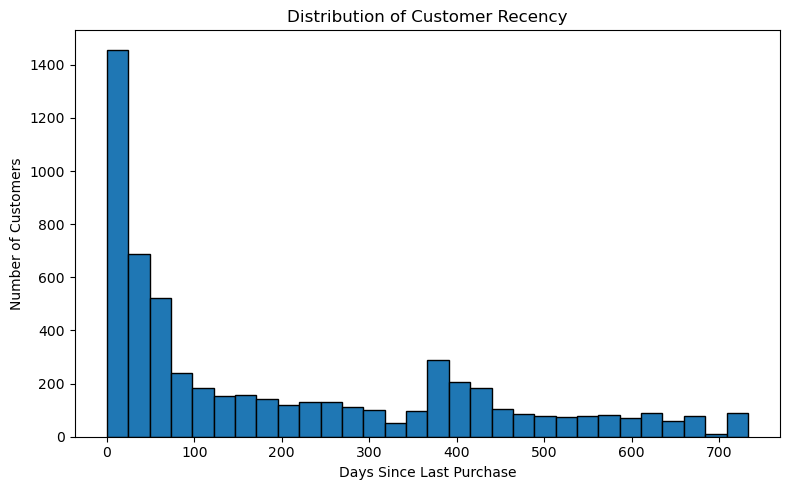

In [42]:
# Recency distribution
plt.figure(figsize=(8,5))

plt.hist(rfm['Recency'], bins=30, edgecolor='black')

plt.title('Distribution of Customer Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

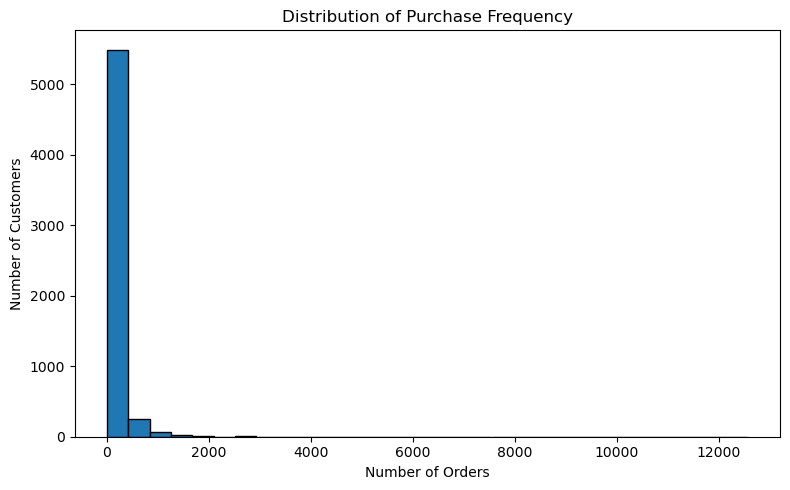

In [43]:
# Frequency distribution
plt.figure(figsize=(8,5))

plt.hist(rfm['Frequency'], bins=30, edgecolor='black')

plt.title('Distribution of Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

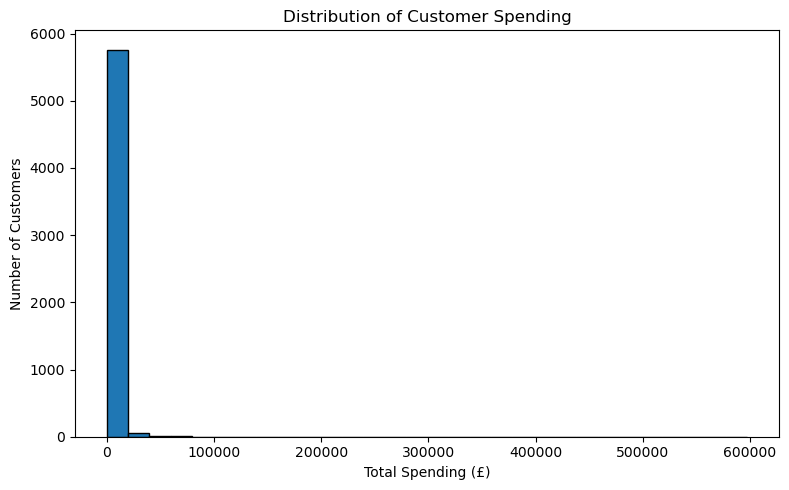

In [44]:
# Monetary distribution
plt.figure(figsize=(8,5))

plt.hist(rfm['Monetary'], bins=30, edgecolor='black')

plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending (£)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

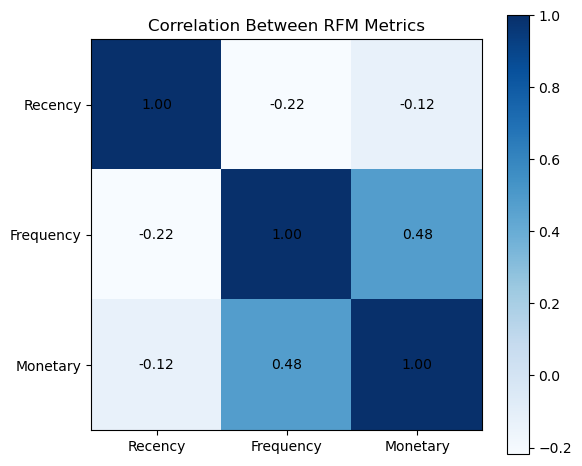

In [45]:
# correlation matrix
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap='Blues')

plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)

for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}',
                 ha='center', va='center')

plt.colorbar()
plt.title('Correlation Between RFM Metrics')

plt.tight_layout()
plt.show()

##### Key Takeaways:
- **Customer purchasing behavior is highly heterogeneous.** The distributions of Frequency and Monetary are strongly right-skewed, indicating that a relatively small group of customers accounts for a disproportionately large share of purchases and total spending.
- **The RFM metrics capture different aspects of customer behavior.** The relatively weak to moderate correlations suggest that Recency, Frequency, and Monetary provide complementary information rather than measuring the same characteristic. Therefore, all three metrics should be considered when evaluating customer value.
- **Repeat purchasing is associated with higher customer value.** Customers who purchase more frequently generally contribute more revenue, highlighting the importance of retaining loyal customers and encouraging repeat purchases.
- **Recent activity alone does not fully explain customer value.** Some customers who have generated substantial historical revenue may no longer be actively purchasing, suggesting opportunities for targeted re-engagement campaigns.

Overall, these findings indicate that customers exhibit diverse purchasing behaviors and value levels. A single marketing strategy is therefore unlikely to be equally effective for the entire customer base, supporting the need for customer segmentation before designing personalized marketing campaigns.

#### RFM Score Conversion
##### Individual RFM dimension label
Although the customer-level RMF dataset already contains the raw **Recency**, **Frequency**, and **Monetary** values, these variables are measured on different scales/units. For example, Recency is measured in days, Frequency represents the number of purchases, and Monetary reflects the total amount spent. Directly comparing these raw values makes it difficult to consistently evaluate customer behaviors.

To create a standardized and interpretable customer segmentation framework, each RFM metric is converted into a score ranging from **1 to 5** based on customer rankings. This scoring process places **all three metrics on the same scale**, allowing them to be combined into an overall customer profile.

Using standardized RFM scores offers two key advantages:

- It provides a consistent way to compare customers across different behavioral dimensions.
- It creates intuitive customer profiles that can be easily understood and applied by marketing teams without requiring technical knowledge of the underlying data.

The resulting RFM scores serve as the basis for assigning customers to meaningful behavioral segments such as **Champions**, **Loyal Customers**, **At Risk**, and **Lost Customers**.

In this project, we use **percentile-based grouping (`qcut`)** to assign RFM scores. The `qcut()` function sorts customers based on each RFM metric and divides them into **five groups of approximately equal size (quintiles)**. Each group is then assigned a score from **1 to 5**, representing the customer's relative ranking compared with the rest of the customer base.

In [48]:
rfm_scores = rfm.copy()
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency
0,12346.0,77556.46,34,320
1,12347.0,5408.50,242,34
2,12348.0,2019.40,51,70
3,12349.0,4428.69,175,13
4,12350.0,334.40,17,304


In [49]:
#Date from customer's last purchase.The nearest date gets 5 and the furthest date gets 1.
rfm_scores['Recency_Score'] = pd.qcut(rfm_scores['Recency'],5,labels=[5,4,3,2,1])
# Total number of purchases. The least frequency gets 1 and the maximum frequency gets 5.
rfm_scores['Frequency_Score'] = pd.qcut(rfm_scores['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
#Total spend by the customer. The least money gets 1, the most money gets 5.
rfm_scores['Monetary_Score'] = pd.qcut(rfm_scores['Monetary'],5,labels=[1,2,3,4,5])

rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score
0,12346.0,77556.46,34,320,2,2,5
1,12347.0,5408.50,242,34,4,5,5
2,12348.0,2019.40,51,70,3,3,4
3,12349.0,4428.69,175,13,5,4,5
4,12350.0,334.40,17,304,2,2,2


Descriptions:
- Best Recency score = 5: most recently purchase.
- Best Frequency score = 5: most number of purchase.
- Best Monetary score = 5: spent the most.

Here are our dimensions:

Recency (R):

- Label 5: "Very Recent"
- Label 4: "Recent"
- Label 3: "Moderate"
- Label 2: "Infrequent"
- Label 1: "Very Infrequent"

Frequency (F):

- Label 5: "Very Frequent"
- Label 4: "Frequent"
- Label 3: "Moderate"
- Label 2: "Infrequent"
- Label 1: "Very Infrequent"

Monetary (M):

- Label 5: "High Spending"
- Label 4: "Above Average Spending"
- Label 3: "Average Spending"
- Label 2: "Below Average Spending"
- Label 1: "Low Spending"

##### Combined RFM Labels
After assigning individual scores for **Recency (R)**, **Frequency (F)**, and **Monetary (M)**, the three scores are concatenated to form a three-digit RFM code (e.g., **543**). This combined score summarizes a customer's purchasing behavior across all three dimensions and serves as the basis for customer segmentation.

For example, a customer with an RFM score of **543** represents a customer who purchased very recently, buys relatively frequently, and has moderate overall spending.

The scoring direction reflects the business objective of identifying valuable and engaged customers. Customers who have purchased more recently receive higher **Recency** scores because recent activity indicates stronger engagement and a lower likelihood of churn. Likewise, customers who purchase more frequently and spend more receive higher **Frequency** and **Monetary** scores, as these customers typically contribute greater long-term value to the business.

In [51]:
# Method 1: Concatenate the RFM scores to create a combined RFM score
rfm_scores['RFM_Score_Segment'] = (rfm_scores['Recency_Score'].astype(str)+rfm_scores['Frequency_Score'].astype(str)+rfm_scores['Monetary_Score'].astype(str))
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment
0,12346.0,77556.46,34,320,2,2,5,225
1,12347.0,5408.50,242,34,4,5,5,455
2,12348.0,2019.40,51,70,3,3,4,334
3,12349.0,4428.69,175,13,5,4,5,545
4,12350.0,334.40,17,304,2,2,2,222


##### Segmentation using RFM score segments
Based on Recency & Frequency Score, we create the following business segments:
- can't loose them → A class of customers who used to shop very frequently but have not shopped for a long time and should not be lost.
- at risk → A class of customers who shop relatively frequently but have not shopped for a long time.
- hibernating → Customers who are literally asleep, both shopped infrequently and have not shopped for a long time.
- about to sleep → A class of customers who do not shop frequently and have not shopped for some time; they are heading towards sleep.
- need attention → This is the class of customers in the middle of the RF graph (33%), moving towards the risky group if not addressed.
- new customers → A class of customers who have not shopped frequently (maybe once) and have been shopping for a short period of time, they are considered as new customers.
- promising → New customers are the aged version of new customers :) they are customers who have not shopped frequently and have shopped for a short period of time.
- potential loyalists → Customers who shop moderately often and it has not been long since their last purchase.
- loyal customers → Customers who shop very often and it has been a short time since their last purchase.
- champions → They are our champions, our crown jewels! Customers who shop very often and have made their last purchase within a very short period of time.

In [ ]:
# Segmentation using RFM score segments
rfm_scores.groupby(['RFM_Score_Segment']).size().sort_values(ascending=False)[:10]

RFM_Score_Segment
555    411
111    350
455    260
211    198
122    173
344    169
222    166
444    149
233    138
333    135
dtype: int64

In [59]:
segment_mapping = {r'[1-2][1-2][1-5]': 'Hibernating',
                   r'[1-2][3-4][1-5]': 'At Risk',
                   r'[1-2][5][1-5]': 'Can\'t Loose',
                   r'[3][1-2][1-5]': 'About to Sleep',
                   r'[3][3][1-5]': 'Need Attention',
                   r'[3-4][4-5][1-5]': 'Loyal Customers',
                   r'[4][1][1-5]': 'Promising',
                   r'[5][1][1-5]': 'New Customers',
                   r'[4-5][2-3][1-5]': 'Potential Loyalists',
                   r'[5][4-5][1-5]': 'Champions'
                  }

In [60]:
rfm_scores['Segment'] = rfm_scores['RFM_Score_Segment'].replace(segment_mapping,regex=True)
#rfm_scores.reset_index(inplace=True)
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment
0,12346.0,77556.46,34,320,2,2,5,225,9,Silver,Hibernating
1,12347.0,5408.50,242,34,4,5,5,455,14,Gold,Loyal Customers
2,12348.0,2019.40,51,70,3,3,4,334,10,Gold,Need Attention
3,12349.0,4428.69,175,13,5,4,5,545,14,Gold,Champions
4,12350.0,334.40,17,304,2,2,2,222,6,Silver,Hibernating


In [61]:
rfm_scores.groupby(['Segment']).agg({"Customer ID":"count"}).sort_values("Customer ID",ascending=False)

,Customer ID
Segment,
Hibernating,1422
Loyal Customers,1122
Champions,822
At Risk,803
Potential Loyalists,692
About to Sleep,422
Need Attention,256
Promising,121
Can't Loose,115


In [62]:
rfm_scores[["Segment", "Recency","Frequency","Monetary"]].groupby("Segment").agg(["mean","count","max"]).round()

Recency            Frequency              Monetary        \
                       mean count  max      mean count    max     mean count   
Segment                                                                        
About to Sleep        112.0   422  191      18.0   422     37    677.0   422   
At Risk               392.0   803  733      73.0   803    176   1294.0   803   
Can't Loose           345.0   115  618     323.0   115   2796   4454.0   115   
Champions               8.0   822   18     435.0   822  12573  10671.0   822   
Hibernating           449.0  1422  733      16.0  1422     37    515.0  1422   
Loyal Customers        65.0  1122  191     235.0  1122   1780   4208.0  1122   
Need Attention        110.0   256  191      54.0   256     75   1418.0   256   
New Customers           9.0    85   18       9.0    85     16    528.0    85   
Potential Loyalists    26.0   692   58      43.0   692     76   1172.0   692   
Promising              38.0   121   58       9.0   121     16    357.0   121   

                               
                          max  
Segment                        
About to Sleep        39916.0  
At Risk               67502.0  
Can't Loose           56600.0  
Champions            597336.0  
Hibernating           77556.0  
Loyal Customers      193352.0  
Need Attention        16246.0  
New Customers          8757.0  
Potential Loyalists   30393.0  
Promising              5120.0

- **About to Sleep:** 422
- **At Risk:** 803
- **Can't Loose:** 115
- **Champions:** 822
- **Hibernating:** 1422
- **Loyal Customers:** 1122
- **Need Attention:** 256
- **New Customers:** 85
- **Potential Loyalists:** 692
- **Promising:** 121

##### Segmentation using RFM Score Segments (Business-Interpretation View)

This second mapping uses the same three-digit RFM code but groups customers around a simpler business question for each: *how recent, how frequent, and how big-spending are they* — rather than the finer 10-way split above. Business interpretation for each of the 6 groups:

- **Best Customers** (R, F, and M all in the top 2 quintiles) — bought recently, buy often, and spend the most. The highest-value group overall; strong candidates for VIP treatment, loyalty perks, and referral programs, since they combine all three dimensions of value.
- **Loyal Customers** (high Frequency, regardless of Recency or Monetary) — habitual repeat purchasers. Even if any single order is modest, they generate predictable recurring revenue and are worth retaining through consistent engagement (e.g., replenishment reminders, subscription-style offers).
- **Big Spenders** (high Monetary, regardless of Recency or Frequency) — customers who make large purchases even if infrequently, which may include wholesale/bulk buyers given this company's customer base. Good targets for cross-sell and upsell, since a single order already shows willingness to spend.
- **Almost Lost** (moderately low Recency) — customers who haven't purchased very recently but aren't fully inactive yet. This is the window for proactive re-engagement (targeted offers, check-in emails) before they slip into "Lost."
- **Lost Customers** (lowest Recency) — the longest-inactive customers. Generally the lowest priority for expensive retention spend, except where historical Frequency/Monetary was high, which may justify a one-time win-back attempt.
- **Recent Active Low Spender** (recent, but low Frequency and Monetary) — customers who've purchased recently but only casually and cheaply — likely newer or occasional shoppers. Good onboarding/nurture targets to build purchase habit and grow spend over time.

Note that because these rules are applied in order (a code that matches an earlier pattern, like "Best Customers," is claimed by that label before later, broader patterns like "Loyal Customers" are checked), the groups are not mutually exclusive by definition alone — the mapping order encodes a priority ranking of "what matters most" for a given customer.

In [63]:
# Segmentation using RFM score segments + business interpretations
segment_mapping = {r'[4-5][4-5][4-5]': 'Best Customers',
                   r'[1-5][4-5][1-5]': 'Loyal Customers',
                   r'[1-5][1-5][4-5]': 'Big Spenders',
                   r'[2-3][1-5][1-5]': 'Almost Lost',
                   r'[1][1-5][1-5]': 'Lost Customers',
                   r'[4-5][1-3][1-3]': 'Recent Active Low Spender',
                  }

In [64]:
rfm_scores['Segment_New'] = rfm_scores['RFM_Score_Segment'].replace(segment_mapping,regex=True)
#rfm_scores.reset_index(inplace=True)
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment,Segment_New
0,12346.0,77556.46,34,320,2,2,5,225,9,Silver,Hibernating,Big Spenders
1,12347.0,5408.50,242,34,4,5,5,455,14,Gold,Loyal Customers,Best Customers
2,12348.0,2019.40,51,70,3,3,4,334,10,Gold,Need Attention,Big Spenders
3,12349.0,4428.69,175,13,5,4,5,545,14,Gold,Champions,Best Customers
4,12350.0,334.40,17,304,2,2,2,222,6,Silver,Hibernating,Almost Lost


In [65]:
rfm_scores.groupby(['Segment_New']).agg({"Customer ID":"count"}).sort_values("Customer ID",ascending=False)

,Customer ID
Segment_New,
Almost Lost,1365
Best Customers,1257
Loyal Customers,1087
Lost Customers,978
Recent Active Low Spender,731
Big Spenders,442


- **Almost Lost:**	1365
- **Best Customers:**	1257
- **Loyal Customers:**	1087
- **Lost Customers:**	978
- **Recent Active Low Spender:**	731
- **Big Spenders:**	442

In [57]:
# Method 2: Sum the RFM scores to create a combined RFM score
rfm_scores['RFM_Score_Sum'] = rfm_scores[['Recency_Score','Frequency_Score','Monetary_Score']].sum(axis=1)
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name
0,12346.0,77556.46,34,320,2,2,5,225,9,Silver
1,12347.0,5408.50,242,34,4,5,5,455,14,Gold
2,12348.0,2019.40,51,70,3,3,4,334,10,Gold
3,12349.0,4428.69,175,13,5,4,5,545,14,Gold
4,12350.0,334.40,17,304,2,2,2,222,6,Silver


In [53]:
# Segmentation using RFM_score_sum
rfm_scores.groupby(['RFM_Score_Sum']).agg({'Recency': 'mean',
                                           'Frequency': 'mean',
                                           'Monetary': ['mean', 'count']}).round(1)

Recency Frequency Monetary      
                 mean      mean     mean count
RFM_Score_Sum                                 
3               565.0       7.6    140.5   350
4               441.2      12.9    202.5   397
5               376.2      20.0    323.4   480
6               280.0      24.2    417.7   505
7               245.6      32.9    702.9   502
8               210.1      48.5    937.4   477
9               167.6      61.5   1407.4   513
10              131.6      79.0   1380.4   444
11               98.2     111.4   2168.4   480
12               69.2     167.6   2918.7   451
13               41.3     222.2   3836.6   420
14               23.6     349.7   7223.9   430
15                8.0     692.7  18538.7   411

##### Segmentation Using RFM Score Sum (Gold / Silver / Bronze Tiers)

Unlike the two mappings above — which describe *why* a customer is valuable (recent vs. frequent vs. big-spending) — this third scheme collapses Recency, Frequency, and Monetary scores into a single composite number (`RFM_Score_Sum`, ranging 3–15) and buckets customers into three broad priority tiers. It trades behavioral nuance for simplicity, which is useful when the goal is quick resource allocation rather than a detailed customer profile:

- **Gold (RFM_Score_Sum > 9):** Customers who score well across recency, frequency, and monetary combined — the core, highest-priority revenue drivers. Business focus: retention and loyalty investment (VIP perks, early access, personal outreach) to protect this group from competitor poaching.
- **Silver (6 ≤ RFM_Score_Sum ≤ 9):** Moderate combined engagement — meaningfully active but not top-tier. Business focus: growth/upsell campaigns aimed at nudging them toward Gold (e.g., loyalty program enrollment, targeted promotions).
- **Bronze (RFM_Score_Sum ≤ 5):** Lowest combined engagement across all three dimensions. Business focus: low-cost, largely automated reactivation attempts rather than heavy investment; also a natural candidate list for periodic list-hygiene review.

Because this tiering is a simple sum, two customers can land in the same tier for very different reasons (e.g., high Frequency + low Monetary vs. low Frequency + high Monetary both averaging to "Silver") — it's best used as a coarse prioritization filter alongside, not instead of, the more descriptive segment labels above.

In [54]:
def segments(df):
    if df['RFM_Score_Sum'] > 9 :
        return 'Gold'
    elif (df['RFM_Score_Sum'] > 5) and (df['RFM_Score_Sum'] <= 9 ):
        return 'Silver'
    else:  
        return 'Bronze'

In [55]:
rfm_scores['Segment Name'] = rfm_scores.apply(segments,axis=1)
rfm_scores.head()

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name
0,12346.0,77556.46,34,320,2,2,5,225,9,Silver
1,12347.0,5408.50,242,34,4,5,5,455,14,Gold
2,12348.0,2019.40,51,70,3,3,4,334,10,Gold
3,12349.0,4428.69,175,13,5,4,5,545,14,Gold
4,12350.0,334.40,17,304,2,2,2,222,6,Silver


In [56]:
rfm_scores.groupby(['Segment Name']).agg({'Recency':'mean',
                                         'Frequency':'mean',
                                         'Monetary':['mean','count']}).round(1).sort_values(by=('Monetary','count'), 
                                                                                            ascending=False)

Recency Frequency Monetary      
                mean      mean     mean count
Segment Name                                 
Gold            63.6     262.7   5807.0  2636
Silver         225.8      41.8    867.8  1997
Bronze         451.1      14.2    232.1  1227

- **Gold Customers:** 2,636
- **Silver Customers:** 1,997
- **Bronze Customers:** 1,227

### 5. Methodology 2 - K-Means Clustering
In addition to the rule-based RFM segmentation, this project also applies **K-Means clustering**, a widely used **unsupervised machine learning algorithm** for customer segmentation. Unlike RFM segmentation, which relies on predefined business rules, K-Means automatically groups customers based on similarities in their purchasing behavior.

The purpose of applying K-Means is not to replace the RFM framework, but to complement it by exploring whether the customer data naturally forms distinct behavioral groups. Comparing the two approaches provides additional insights into customer behavior and helps validate whether the rule-based segmentation aligns with patterns identified directly from the data.

#### Data Preparation for K-Means Clustering
Before applying K-Means clustering, the input data should be prepared appropriately. Since K-Means is a distance-based algorithm, variables measured on different scales can disproportionately influence the clustering results. In addition, highly skewed variables and extreme outliers may distort the cluster centers.

The following preprocessing steps are performed before model training:

- Examine the distribution of the RFM variables.
- Apply logarithmic transformation to reduce skewness, if necessary.
- Standardize the variables so that Recency, Frequency, and Monetary contribute equally to the distance calculation.
- Evaluate the appropriate number of clusters using the Elbow Method and Silhouette Score.

In [66]:
# Prep 1: Check key assumptions of K-Means clustering
rfm.describe()

,Monetary,Frequency,Recency
count,5860.000000,5860.000000,5860.000000
mean,2956.473053,135.376962,199.982594
std,14352.382490,346.658807,207.490532
min,2.900000,1.000000,0.000000
25%,344.492500,21.000000,25.000000
50%,883.595000,53.000000,100.000000
75%,2284.647500,141.000000,375.000000
max,597336.110000,12573.000000,733.000000


In [67]:
# 1. Check for skewness in the RFM variables
from scipy.stats import skew

skew_df = pd.DataFrame(columns=['Feature Name', 'Skewness'])

rfm_metrics = ['Recency','Monetary', 'Frequency']

for feature in rfm_metrics:
    skewness = skew(rfm[feature])
    skew_df = skew_df._append({'Feature Name': feature, 'Skewness': skewness}, ignore_index=True)

print(skew_df)

  Feature Name   Skewness
0      Recency   0.879347
1     Monetary  25.762005
2    Frequency  17.838608


In [71]:
# Solution for 2: Log Transformation
rfm_log_transform = rfm[['Frequency', 'Monetary']].apply(np.log, axis = 1).round(3)

skew_log_transform_df = pd.DataFrame(columns=['Feature Name', 'Skewness'])

rfm_lof_transform_features = ['Monetary','Frequency']

for feature in rfm_lof_transform_features:
    skewness = skew(rfm_log_transform[feature])
    skew_log_transform_df = skew_log_transform_df._append({'Feature Name': feature, 'Skewness': skewness}, ignore_index=True)

print(skew_log_transform_df)

  Feature Name  Skewness
0     Monetary  0.236373
1    Frequency -0.223231


In [72]:
rfm_log_transform.head()

,Frequency,Monetary
0,3.526,11.259
1,5.489,8.596
2,3.932,7.611
3,5.165,8.396
4,2.833,5.812


Now the skewness of all three RFM dimensions lies between -1 to 1 which is acceptable for further processing.

In [73]:
rfm_log_transform['Customer ID'] = rfm['Customer ID']
rfm_log_transform['Recency'] = rfm['Recency']
rfm_log_transform = rfm_log_transform[['Customer ID','Recency','Frequency','Monetary']]
rfm_log_transform

,Customer ID,Recency,Frequency,Monetary
0,12346.0,320,3.526,11.259
1,12347.0,34,5.489,8.596
2,12348.0,70,3.932,7.611
3,12349.0,13,5.165,8.396
4,12350.0,304,2.833,5.812
...,...,...,...,...
5855,18283.0,4,6.842,7.835
5856,18284.0,426,3.332,6.135
5857,18285.0,655,2.485,6.057
5858,18286.0,471,4.205,7.167


In [74]:
rfm_log_transform = rfm_log_transform[['Customer ID','Recency','Frequency','Monetary']]
rfm_log_transform

,Customer ID,Recency,Frequency,Monetary
0,12346.0,320,3.526,11.259
1,12347.0,34,5.489,8.596
2,12348.0,70,3.932,7.611
3,12349.0,13,5.165,8.396
4,12350.0,304,2.833,5.812
...,...,...,...,...
5855,18283.0,4,6.842,7.835
5856,18284.0,426,3.332,6.135
5857,18285.0,655,2.485,6.057
5858,18286.0,471,4.205,7.167


In [75]:
rfm_log_transform.describe()

,Recency,Frequency,Monetary
count,5860.000000,5860.000000,5860.000000
mean,199.982594,3.939757,6.823284
std,207.490532,1.441456,1.390351
min,0.000000,0.000000,1.065000
25%,25.000000,3.045000,5.841750
50%,100.000000,3.970000,6.784000
75%,375.000000,4.949000,7.734250
max,733.000000,9.439000,13.300000


In [76]:
# 2. Check for equality of mean and variance of the RFM variables
rfm.describe()

,Monetary,Frequency,Recency
count,5860.000000,5860.000000,5860.000000
mean,2956.473053,135.376962,199.982594
std,14352.382490,346.658807,207.490532
min,2.900000,1.000000,0.000000
25%,344.492500,21.000000,25.000000
50%,883.595000,53.000000,100.000000
75%,2284.647500,141.000000,375.000000
max,597336.110000,12573.000000,733.000000


In [77]:
# Solution for 2: Standarizing
rfm_normalization = rfm_log_transform[['Recency','Frequency','Monetary']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(rfm_normalization)
rfm_normalized = scaler.transform(rfm_normalization)
rfm_normalized

array([[ 0.57847289, -0.28706582,  3.19062888],
       [-0.80002088,  1.07486823,  1.27512212],
       [-0.62650418, -0.00538206,  0.56660761],
       ...,
       [ 2.19314217, -1.00931409, -0.55119093],
       [ 1.30627904,  0.18402599,  0.2472366 ],
       [-0.78556115,  0.76543238,  1.09026098]])

#### Chosing Number of Clusters 
**Method 1: Elbow method**

In [78]:
cluster_iteration = range(1,10)
scores = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    scores.append(K_Means.fit(rfm_normalized).score(rfm_normalized))

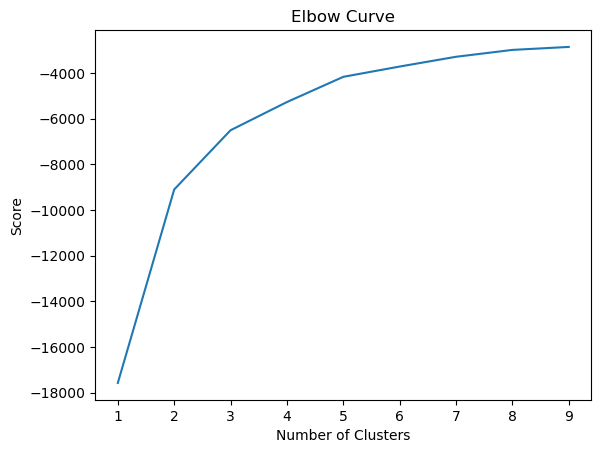

In [79]:
# Elbow Curve (Number of Clusters vs. Score)
plt.plot(cluster_iteration,scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.xticks(cluster_iteration)
plt.style.use('ggplot')
plt.show()

From the Elbow Curve, we found that **optimal number of clusters (n_clusters) is 5**. 

However, it is not always straightforward and there may not be a clear and distinct elbow. In such cases, you might need to use additional methods such as silhouette coefficient or make an informed decision based on domain knowledge and the specific goals of your analysis.

**Method 2: Using `.inertia_` method (Within-Cluster Sum of Sqaures)**

In [81]:
from sklearn.cluster import KMeans

cluster_iteration = range(1,10)
inertias = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    inertias.append(K_Means.inertia_)

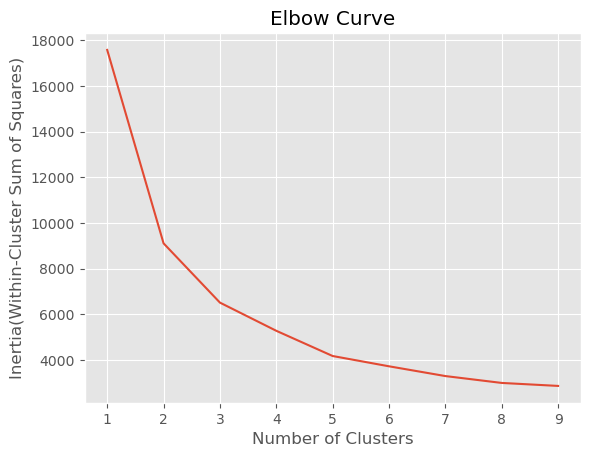

In [82]:
plt.plot(cluster_iteration,inertias)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia(Within-Cluster Sum of Squares)')
plt.title('Elbow Curve')
plt.xticks(cluster_iteration)
plt.style.use('ggplot')
plt.show()

From the Elbow Curve, we found that optimal **number of clusters (n_clusters) is 5**

**Method 3: Silhouette Coefficient**

In [80]:
cluster_iteration = range(2,10)  # Start from at least 2 clusters (Silhouette Score Requirement)
inertias = []

for cluster_number in cluster_iteration:
    K_Means = KMeans(n_clusters=cluster_number, random_state=45)
    K_Means.fit(rfm_normalized)
    clustered_labels = K_Means.labels_
    
    silhouette_avg = silhouette_score(rfm_normalized,clustered_labels)
    print(f'For n_clusters={cluster_number}, the Silhouette score is {silhouette_avg}')

For n_clusters=2, the Silhouette score is 0.410326856557607
For n_clusters=3, the Silhouette score is 0.36436201163241955
For n_clusters=4, the Silhouette score is 0.3506805541447592
For n_clusters=5, the Silhouette score is 0.34302974402158676
For n_clusters=6, the Silhouette score is 0.3086794446002118
For n_clusters=7, the Silhouette score is 0.3068840568245492
For n_clusters=8, the Silhouette score is 0.310948368712617
For n_clusters=9, the Silhouette score is 0.3008266518183137


From the Silhouette Score analysis, the score is actually **highest at k=2 (0.410)** and generally **decreases** as the number of clusters increases (down to ~0.30–0.31 for k=6–9), with only a very small, likely noise-level bump at k=8. Strictly speaking, silhouette score alone does not "confirm" k=5 — it favors fewer, more separated clusters, which is a common pattern in real-world customer data that doesn't split into perfectly distinct groups.

We proceed with **n_clusters = 5** anyway, for two reasons: (1) it sits at the point where the Elbow/inertia curve visibly bends and additional clusters yield diminishing returns, and (2) five clusters produce more actionable, business-relevant granularity than the two broad, less-informative groups a pure silhouette-maximizing choice would give. This is a modeling trade-off — statistical "optimality" vs. business usefulness — and is worth stating explicitly rather than implying the metrics unanimously agree.

#### Final Modeling

In [83]:
K_Means_final_model = KMeans(n_clusters= 5, random_state=45)
K_Means_final_model.fit(rfm_normalized)

KMeans(n_clusters=5, random_state=45)

In [84]:
cluster_labels = K_Means_final_model.labels_
cluster_labels

array([0, 0, 4, ..., 1, 3, 0], dtype=int32)

In [85]:
rfm['Cluster'] = cluster_labels
rfm.head()

,Customer ID,Monetary,Frequency,Recency,Cluster
0,12346.0,77556.46,34,320,0
1,12347.0,5408.50,242,34,0
2,12348.0,2019.40,51,70,4
3,12349.0,4428.69,175,13,0
4,12350.0,334.40,17,304,2


In [86]:
rfm.groupby('Cluster').agg({'Recency': 'mean',
                            'Frequency': 'mean',
                            'Monetary': ['mean', 'count'],}).round(0)

Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0          47.0     447.0  10761.0  1216
1         530.0      13.0    243.0   847
2         109.0      17.0    341.0   994
3         413.0      64.0   1083.0  1059
4          68.0      88.0   1461.0  1744

The bullet list in the original notebook here mislabeled the cluster **Recency means** as cluster sizes. Corrected cluster profile (from the `groupby('Cluster')` output above):

| Cluster | Customers (n) | Avg. Recency (days) | Avg. Frequency (orders) | Avg. Monetary (£) | Likely Profile |
|:---:|---:|---:|---:|---:|:---|
| 0 | 1,216 | 47 | 447 | 10,761 | Champions – very recent, very frequent, highest spend |
| 1 | 847 | 530 | 13 | 243 | Lost / Hibernating – long inactive, low engagement |
| 2 | 994 | 109 | 17 | 341 | Low-value / newer customers – fairly recent but little history |
| 3 | 1,059 | 413 | 64 | 1,083 | At Risk – moderate historical value, going inactive |
| 4 | 1,744 | 68 | 88 | 1,461 | Potential Loyalists – recent, moderately frequent, growing value (largest cluster) |

(Counts sum to 5,860, matching the total customer base.)

In [87]:
rfm_scores['Cluster'] = cluster_labels
rfm_scores

,Customer ID,Monetary,Frequency,Recency,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score_Segment,RFM_Score_Sum,Segment Name,Segment,Segment_New,Cluster
0,12346.0,77556.46,34,320,2,2,5,225,9,Silver,Hibernating,Big Spenders,0
1,12347.0,5408.50,242,34,4,5,5,455,14,Gold,Loyal Customers,Best Customers,0
2,12348.0,2019.40,51,70,3,3,4,334,10,Gold,Need Attention,Big Spenders,4
3,12349.0,4428.69,175,13,5,4,5,545,14,Gold,Champions,Best Customers,0
4,12350.0,334.40,17,304,2,2,2,222,6,Silver,Hibernating,Almost Lost,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5855,18283.0,2528.65,936,4,5,5,4,554,14,Gold,Champions,Best Customers,0
5856,18284.0,461.68,28,426,1,2,2,122,5,Bronze,Hibernating,Lost Customers,3
5857,18285.0,427.00,12,655,1,1,2,112,4,Bronze,Hibernating,Lost Customers,1
5858,18286.0,1296.43,67,471,1,3,4,134,8,Silver,At Risk,Big Spenders,3


After assigning customers to different clusters, the next step is to understand the characteristics of each customer group. Since K-Means itself only assigns cluster labels, the clusters must be interpreted by examining the underlying customer behaviors.

To profile each cluster, boxplots are used to compare the distributions of **Recency**, **Frequency**, and **Monetary** across clusters. By visualizing these RFM metrics, we can identify the behavioral characteristics of each cluster, such as whether customers are recent or inactive purchasers, frequent or occasional shoppers, and high- or low-value customers.

These insights allow each cluster to be translated into meaningful business profiles, which can then support targeted marketing strategies and customer relationship management decisions.

<Figure size 1000x600 with 0 Axes>

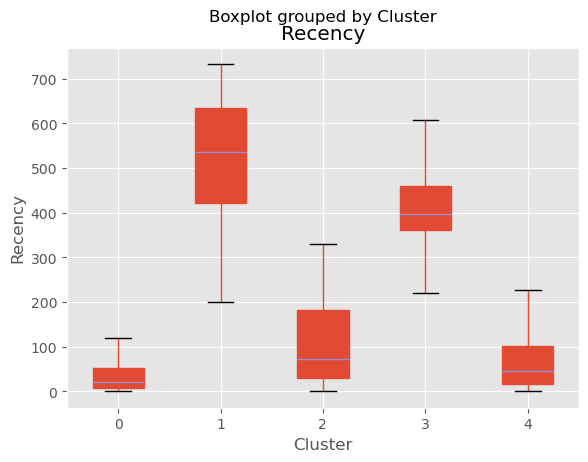

In [88]:
plt.figure(figsize=(10, 6))
rfm_scores.boxplot(column='Recency', by='Cluster', patch_artist=True, showfliers=False)
plt.xlabel('Cluster')
plt.ylabel('Recency')
plt.show()

<Figure size 1000x600 with 0 Axes>

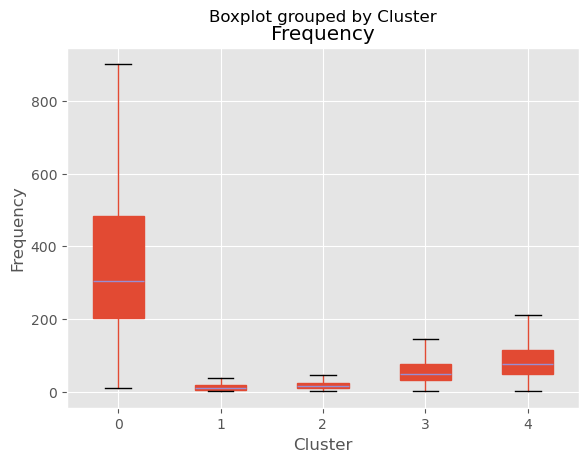

In [89]:
plt.figure(figsize=(10, 6))
rfm_scores.boxplot(column='Frequency', by='Cluster', patch_artist=True, showfliers=False)
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

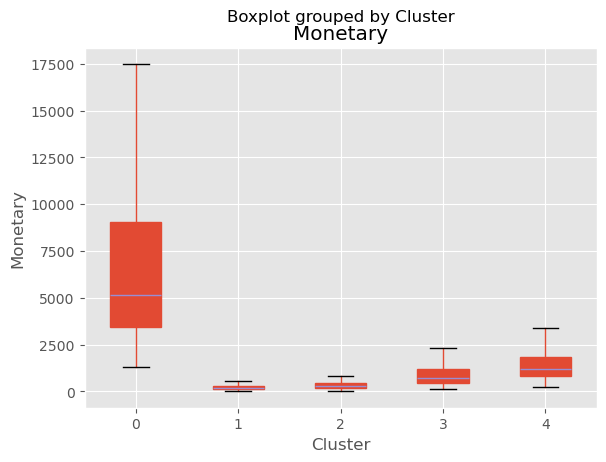

In [90]:
plt.figure(figsize=(10, 6))
rfm_scores.boxplot(column='Monetary', by='Cluster', patch_artist=True, showfliers=False)
plt.xlabel('Cluster')
plt.ylabel('Monetary')
plt.show()

##### Key Takeaways from the Cluster Boxplots

Reading the three boxplots (Recency, Frequency, Monetary by Cluster) together, alongside the cluster means table above, gives a clear behavioral profile for each of the 5 clusters. Note: `showfliers=False` hides extreme outliers in these plots (e.g., the overall max Monetary is £597,336 and max Frequency is 12,573), so the boxes below understate how long the right tail actually is within each cluster.

- **Cluster 0 — Champions (n = 1,216).** Lowest Recency (median ≈ 20 days, almost entirely under 120) combined with by far the highest Frequency (median ≈ 300, IQR ≈ 200–480, up to 900) and Monetary (median ≈ £5,100, IQR ≈ £3,500–£9,000, up to £17,500). This cluster is unambiguously the most valuable, active, and recently-engaged group, and lines up closely with the "Champions"/"Gold" segments from the rule-based RFM scoring.

- **Cluster 1 — Lost / Hibernating (n = 847).** The mirror image of Cluster 0: highest Recency (median ≈ 535 days, IQR ≈ 420–635) and the lowest Frequency and Monetary, both compressed near zero. These customers have been inactive for well over a year on average and contribute almost nothing to recent revenue.

- **Cluster 2 — Low-Value / Newer Customers (n = 994).** Recency is low-to-moderate and much more spread out (median ≈ 70 days, range 0–330) than Cluster 1, but Frequency and Monetary are just as low. The distinguishing feature versus Cluster 1 is recency, not value — these look like customers who are still relatively new or only shop occasionally, rather than customers who have fully disengaged.

- **Cluster 3 — At Risk (n = 1,059).** Recency is high (median ≈ 390 days, IQR ≈ 385–460) but Frequency and Monetary are moderate (median Frequency ≈ 65, median Monetary ≈ £800–1,000, up to £2,400) — noticeably higher than Clusters 1 and 2. These were reasonably valuable customers who have gone quiet, making them a natural priority for win-back campaigns since there's more revenue at stake per customer than in Cluster 1.

- **Cluster 4 — Potential Loyalists / Promising (n = 1,744, the largest cluster).** Recency is low (median ≈ 45 days, mostly under 230) with moderate Frequency (median ≈ 85, up to ≈ 210) and moderate Monetary (median ≈ £1,200–1,500, up to £3,400). This is the largest group in the customer base and sits between "new/casual" and "Champion" — currently active and engaged, but with room to grow into higher-frequency, higher-spend behavior with the right nurturing.

**Overall pattern:** Recency is the dimension that separates the clusters most cleanly (little overlap in the boxes), while Frequency and Monetary distinguish the "high value" (Cluster 0) from the rest more than they separate the three mid/low clusters (1, 2, 3) from each other. This mirrors the K-Means silhouette results discussed above — a coarser split (e.g., "engaged" vs. "not engaged," roughly Recency-driven) is the most statistically distinct structure in the data, and the 5-cluster view adds business-useful nuance on top of that coarser split rather than reflecting 5 equally well-separated groups.

### 6. Improvements

This analysis is a solid first version of an RFM + K-Means segmentation, but a few methodological gaps should be addressed before it is used to drive live marketing decisions:

1. **Fix the Frequency definition.** As flagged in Section 4, Frequency currently counts transaction **line items** (`Invoice.count()`), not distinct **orders** (`Invoice.nunique()`). Since the stated business definition is "number of transactions," switching to `nunique()` is a quick fix, but it will shift the Frequency distribution, the Frequency/RFM scores, and likely some cluster assignments — this should be re-run before the segments are operationalized.

2. **Implement the duplicate-record check.** Section 3's Data Quality Assessment lists duplicate records as something to check, but no `duplicated()` / `drop_duplicates()` step was ever run, and the original summary table's "26,479 duplicates removed" figure didn't correspond to any executed code (now corrected in the Data Cleaning Summary). This should be implemented and re-verified against the real row counts.

3. **Decide explicitly how to treat `Quantity == 0` and cancellations.** The cleaning step keeps `Quantity >= 0`, which retains any zero-quantity rows (these contribute nothing to Monetary but inflate Frequency-as-line-items). Cancelled orders are also only removed indirectly (via negative Quantity) rather than explicitly via the `Invoice` prefix `"C"` used in this dataset — worth cross-checking that the two approaches agree.

4. **Clean up Customer ID formatting.** Customer ID is cast straight from float to string (`astype(str)`), leaving values like `"12346.0"` instead of `"12346"`. Casting to `int` first (`astype(int).astype(str)`) avoids this cosmetic issue, which currently shows up in every customer-level table.

5. **Revisit outlier handling for K-Means.** Log transformation + standardization is a reasonable approach and the described skewness checks are correct, but Recency (skew 0.88) was left untransformed, and no explicit outlier capping/winsorizing was applied to any variable. Given Monetary's original skew of ~25.8 and Frequency's ~17.8, a few extreme customers (e.g., the £597,336 max Monetary customer) may still be exerting outsized pull on the cluster centers even post-transform — worth checking cluster stability with and without those points.

6. **Be more careful with the silhouette-vs-elbow narrative.** As corrected in Section 5, silhouette score is actually highest at k=2 and decreases as k grows — it doesn't independently "confirm" k=5. The choice of 5 is defensible on business-granularity grounds, but should be presented as a trade-off rather than as full agreement between methods.

7. **Cross-validate the two segmentation approaches.** The notebook produces three different rule-based schemes (10-segment RFM map, 6-segment "business interpretation" map, 3-tier Gold/Silver/Bronze) plus a 5-cluster K-Means solution, but never directly compares them. A `pd.crosstab(rfm_scores['Segment'], rfm_scores['Cluster'])` would show how much the data-driven clusters agree with the rule-based segments — strong agreement would build confidence in both; disagreement would be worth investigating.

8. **Tighten redundant cells.** A few cells repeat the same computation without adding new information (e.g., the missing-value check is run identically in both Section 2 and Section 3, and `rfm.describe()` is called twice in the K-Means prep section under different check labels). Consolidating these would make the notebook easier to follow.

9. **Add a stability check for K-Means.** Only a single `random_state=45` was tested for the final model. Running K-Means with multiple seeds (or `n_init` explicitly set higher) and checking that cluster assignments are consistent would strengthen confidence that 5 clusters is a stable, not incidental, solution.

### 7. Conclusion

Starting from roughly 1.05 million raw transaction line items, this project cleaned the data down to 793,309 valid transactions covering 5,860 unique customers, and used the Recency, Frequency, and Monetary (RFM) framework to translate that transaction history into a customer-level view of purchasing behavior.

Two complementary segmentation lenses were applied to the same RFM features:

- **Rule-based RFM scoring** (quintile scores combined into 10 classic segments, a simplified 6-segment business view, and a 3-tier Gold/Silver/Bronze rollup), which is transparent, easy to explain to a marketing team, and directly actionable without a model in the loop.
- **K-Means clustering** on log-transformed, standardized RFM features (k = 5, chosen via the Elbow method and cross-checked, with caveats, against Silhouette scores), which lets the data reveal its own groupings rather than relying on fixed business thresholds.

Both approaches converge on a similar underlying structure: a small, highly valuable, highly engaged group (Champions / Gold / Cluster 0); a much larger group that has gone quiet with little historical value (Hibernating–Lost / Bronze / Cluster 1); and several intermediate groups distinguished mainly by how recently they've purchased relative to how much they historically spent (At Risk, Potential Loyalists, Need Attention / Cluster 2–4). This convergence across two independent methods is itself a useful validation signal, even without formally cross-tabulating the two (see Improvements, #7).

The core finding — that customer value and engagement are highly concentrated and unevenly distributed — directly supports the project's original objective: a single, undifferentiated email campaign is leaving both revenue and retention on the table. The segments and clusters produced here give the marketing team a concrete, data-driven starting point for personalized outreach, addressed in the next section.

### 8. Business Application & Next Steps

#### Translating Segments into Marketing Actions

| Segment / Cluster | Profile | Recommended Action |
|---|---|---|
| Champions / Gold / Cluster 0 | Very recent, very frequent, highest spend | Protect and deepen the relationship: VIP recognition, early access to new products, loyalty perks, referral requests. Avoid generic discounting — these customers don't need a coupon to buy. |
| Loyal Customers / Potential Loyalists / Cluster 4 | Recent, moderately frequent, moderate-to-growing spend (largest group) | Nurture toward Champion status: cross-sell/upsell campaigns, loyalty program enrollment, personalized product recommendations. Highest-leverage segment given its size. |
| At Risk / Can't Lose Them / Cluster 3 | Previously valuable, now inactive | Prioritized win-back campaigns with personalized incentives, ideally before they fully lapse; prioritize by historical Monetary value since more revenue is at stake per customer than in the fully-lost group. |
| Need Attention / New / Promising | Short history, moderate engagement | Onboarding sequences, second-purchase incentives, education content to build habit before they drift into "About to Sleep." |
| Hibernating / Lost / Bronze / Cluster 1 | Long inactive, minimal historical value | Low-cost reactivation email (or a single "win-back" test) rather than ongoing full-price campaign spend; consider suppressing from paid retargeting to protect CAC, and periodically prune truly unresponsive contacts. |

#### Recommended Next Steps

1. **Fix the Frequency metric and re-run** (see Improvements #1) before these segments are pushed into a live campaign — this affects who ends up in each group.
2. **Operationalize the segments**: sync Customer ID + Segment/Cluster labels to the email platform/CRM so campaigns can be targeted rather than blasted to the full list.
3. **Design an A/B test on the highest-leverage segment first.** For example, on the **At Risk** segment (n ≈ 1,059):
   - **Hypothesis:** A personalized win-back email (referencing past purchase category, with a targeted incentive) drives a higher repeat-purchase rate than the current one-size-fits-all email.
   - **Design:** Randomly split the segment into a treatment group (new personalized email) and a control group (existing generic email, or no email, depending on what's being isolated). Keep everything else (timing, channel) constant.
   - **Primary metric:** 30–60 day repeat purchase rate (ties directly to the "Repeat purchase rate" and "Revenue per customer" success metrics defined in the Executive Summary). Secondary metrics: open rate, CTR, conversion rate.
   - **Sample size / power:** With ~1,000 customers in this segment, a standard power calculation (e.g., detecting a 5–10 percentage-point lift at 80% power, α = 0.05) should be run before launch to confirm the segment is large enough to reach significance; if not, consider testing on a broader "At Risk + Can't Lose Them" pool.
   - **Guardrails:** Pre-register the test duration and stopping rule to avoid peeking/early-stopping bias.
4. **Extend testing to other segments** once a workflow is proven: e.g., test cadence/frequency for Champions (does more frequent contact increase or fatigue engagement?), and test onboarding sequence variants for New/Promising customers.
5. **Track success metrics by segment, not just in aggregate** — the Executive Summary's metrics (open rate, CTR, conversion, repeat purchase rate, revenue/customer, retention) should be reported per segment so lift from personalization can be attributed to the segmentation strategy itself, not just to email in general.
6. **Establish a refresh cadence.** RFM values and cluster membership will drift as customers transact (or don't). Recomputing this pipeline monthly or quarterly, and tracking how customers migrate between segments over time (e.g., what fraction of "Potential Loyalists" become "Champions" after a nurture campaign), turns this from a one-time analysis into an ongoing CRM feedback loop.
7. **Feed A/B test results back into segmentation strategy** — if certain segments respond much better/worse than expected, that's a signal to revisit segment boundaries (e.g., the qcut quintile cutoffs) or the number of K-Means clusters, rather than treating the current segmentation as final.